In [9]:
#!python.exe -m pip install --upgrade pip > None

In [10]:
#!pip install numba > None

In [11]:
#!pip install numpy > None

In [12]:
#!pip install matplotlib > None

In [13]:
#!pip install memory_profiler > None

In [22]:
#!pip install tqdm > None

In [28]:
#!pip install scipy > None

In [5]:
import numpy as np
import numba as nb
import matplotlib.pyplot as plt
import psutil, os
import matplotlib.pyplot as plt
import scipy as sp
%load_ext memory_profiler

The memory_profiler extension is already loaded. To reload it, use:
  %reload_ext memory_profiler


1. Изучите реализацию многомерных массивов numpy.ndarray и работу с ними в numba.

Выполнено :)

2. Реализуйте произведение матриц $A\in Mat(N\times K)$, $B\in Mat(K\times M)$ согласно определению
$$
C_{n,m}=\sum_{k=1}^K A_{n,k}B_{k,m}.
$$
Сравните быстродействие реализаций на основе numpy.sum, с помощью numba и стандартный метод numpy.dot.
Насколько полно используется процессор? 
Сколько используется памяти?

In [6]:
def npsum(a,b,c):
    for n in range(a.shape[0]):
        for m in range(b.shape[1]):
            c[n][m] = np.sum(a[n,:] * b[:,m])
            #for k in range(a.shape[1]):
            #    c[n][m]+=a[n][k]*b[k][m]

@nb.njit(nb.void(nb.float64[:,:], nb.float64[:,:], nb.float64[:, :]))
def numba_mult(a,b,c):
    for n in nb.prange(a.shape[0]):
        for m in nb.prange(b.shape[1]):
            c[n][m] = np.sum(a[n,:] * b[:,m])
            #for k in nb.prange(a.shape[1]):
            #    c[n][m]+=a[n][k]*b[k][m]
            

In [7]:
#pid = os.getpid()
#py_proc = psutil.Process(pid)

N=500
K=400
M=300
# a = np.arange(N*K, dtype=np.float64).reshape((N,K))
# b = np.arange(K*M, dtype=np.float64).reshape((K,M))
a = np.random.rand(N,K)
b = np.random.rand(K, M)

c=np.zeros((N,M))

In [8]:
%timeit npsum(a,b,c)
%memit npsum(a,b,c)

1.15 s ± 43.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
peak memory: 171.83 MiB, increment: 0.06 MiB


In [9]:
%timeit numba_mult(a,b,c)
%memit numba_mult(a,b,c)

139 ms ± 2.29 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
peak memory: 171.86 MiB, increment: 0.00 MiB


In [10]:
%timeit np.dot(a,b)
%memit np.dot(a,b)

2.15 ms ± 47.9 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
peak memory: 172.98 MiB, increment: 0.00 MiB


3. Составьте модель использования вычислительных ресурсов функцией на основе numba.jit из предыдущего пункта.
Размеры матриц должны быть параметрами модели.
Проведите вычислительные эксперименты, чтобы подобрать параметры модели.
Экстраполируйте результат на большие матрицы, сделайте экспериментальную проверку.

In [11]:
from timeit import default_timer as timer
from gc import collect as gc
from tqdm.notebook import tqdm

In [12]:
gc()

def time_m_mult(n1:int, iters:int=100):
    n2 = n1
    n3 = n1
    # может быть интересным рассмотреть модель не только для квадратных матриц, но пока оставлю так
    times = np.zeros(iters)
    for i in tqdm(range(iters), desc="Iterations"):
        a = np.random.rand(n1,n2)
        b = np.random.rand(n2,n3)
        c=np.zeros((n1,n3))
        t0 = timer()
        numba_mult(a,b,c)
        t = timer()
        times[i] = t-t0
    return times        

In [13]:
dims = [1,10,100,200,300,400,500,1000]
ts = np.zeros((len(dims),2))
for k in tqdm(range(len(dims)), desc="Sizes"):
    time = time_m_mult(dims[k])
    ts[k,:] = [np.min(time), np.average(time)]

Sizes:   0%|          | 0/8 [00:00<?, ?it/s]

Iterations:   0%|          | 0/100 [00:00<?, ?it/s]

Iterations:   0%|          | 0/100 [00:00<?, ?it/s]

Iterations:   0%|          | 0/100 [00:00<?, ?it/s]

Iterations:   0%|          | 0/100 [00:00<?, ?it/s]

Iterations:   0%|          | 0/100 [00:00<?, ?it/s]

Iterations:   0%|          | 0/100 [00:00<?, ?it/s]

Iterations:   0%|          | 0/100 [00:00<?, ?it/s]

Iterations:   0%|          | 0/100 [00:00<?, ?it/s]

min fit: -1.16e-02+(5.74e-04)x+(-2.93e-06)x^2+(6.56e-09)x^3
|p2/p3|= 446.77579126040627
avg fit: -1.26e-02+(6.35e-04)x+(-3.25e-06)x^2+(7.04e-09)x^3
|p2/p3|= 462.1600331939248


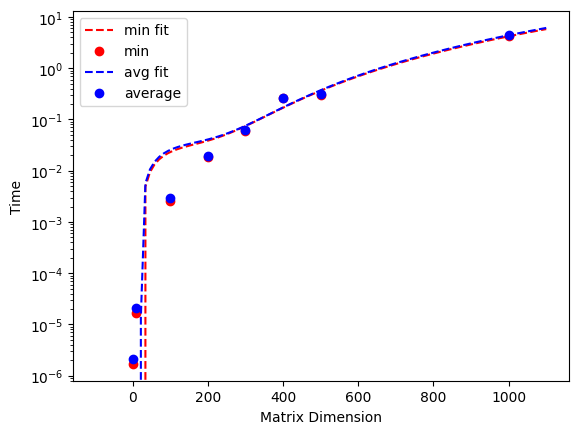

In [14]:
def poly3(x, p0, p1, p2, p3):
    return p0+p1*x+p2*x**2+p3*x**3
    
[p00, p10, p20, p30], _ = sp.optimize.curve_fit(poly3, dims,ts[:,0])
[p01, p11, p21, p31], _ = sp.optimize.curve_fit(poly3, dims,ts[:,1])

canv = np.linspace(dims[0]-(dims[-1]-dims[0])/10,dims[-1]+(dims[-1]-dims[0])/10,100)

print(f'min fit: {p00:.2e}+({p10:.2e})x+({p20:.2e})x^2+({p30:.2e})x^3')
print(f'|p2/p3|= {abs(p20/p30)}')
plt.plot(canv,[poly3(x, p00, p10, p20, p30) for x in canv],'r--',label='min fit')
plt.plot(dims,ts[:,0],'ro',label='min')

print(f'avg fit: {p01:.2e}+({p11:.2e})x+({p21:.2e})x^2+({p31:.2e})x^3')
print(f'|p2/p3|= {abs(p21/p31)}')
plt.plot(canv,[poly3(x, p01, p11, p21, p31) for x in canv],'b--',label='avg fit')
plt.plot(dims,ts[:,1],'bo',label='average')

plt.gca().set_yscale('log')
plt.ylabel('Time')
plt.xlabel('Matrix Dimension')
plt.legend()
plt.show()

Так, мы осуществили полиномиальную аппроксимацию зависимости времени умножения квадратных матриц от их размера кубическим полиномом. Выбор 3 степени как максимальной обусловлен сложностью прямого перемножения $O(n^3)$. Можно заметить, что в использованном методе кубическое слагаемое аппроксимации начинает преобладать в больших матрицах с $n>500$)

In [ ]:
big = 2000
time = time_m_mult(big, iters=50)
bigt = [np.min(time), np.average(time)]

Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
canv = np.linspace(dims[0]-(big-dims[0])/10,big+(big-dims[0])/10,200)

plt.plot(canv,[poly3(x, p00, p10, p20, p30) for x in canv],'r--',label='min fit')
plt.plot(dims,ts[:,0],'ro',label='min')
plt.plot(big,bigt[0],'ro')

plt.plot(canv,[poly3(x, p01, p11, p21, p31) for x in canv],'b--',label='avg fit')
plt.plot(dims,ts[:,1],'bo',label='average')
plt.plot(big,bigt[1],'bo')

plt.gca().set_yscale('log')
plt.ylabel('Time')
plt.xlabel('Matrix Dimension')
plt.legend()
plt.show()